In [1]:
# import all necessary library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
#  Import dataset

train = pd.read_csv("/kaggle/input/titanic/train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test = pd.read_csv("/kaggle/input/titanic/test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Data Preprocessing

train.drop('Cabin', axis=1, inplace=True)
train['Age'].fillna(method = 'bfill', inplace=True)
train['Embarked'].fillna(value='C', inplace=True)

In [7]:
test.drop('Cabin', axis=1, inplace=True)
test['Age'].fillna(method = 'ffill', inplace=True)


In [8]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [9]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

In [10]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,26.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [11]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,"Ware, Mr. Frederick",male,38.5,0,0,359309,8.0500,S


**Perform EDA on train dataset**

In [12]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [13]:
# bar graph on embarked distribution

train['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [14]:
ev = train['Embarked'].value_counts()
ev

S    644
C    170
Q     77
Name: Embarked, dtype: int64

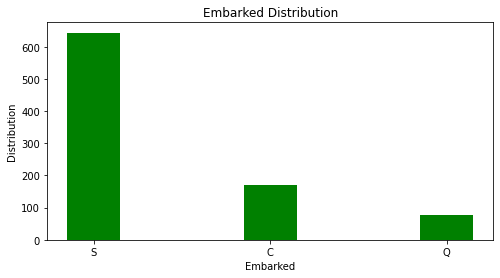

In [15]:
fig = plt.figure(figsize = (8, 4))

# Creating a Bar plot
plt.bar(ev.index, ev, color='Green', width=0.3)

plt.title('Embarked Distribution')
plt.xlabel('Embarked')
plt.ylabel('Distribution')
plt.show()

(array([ 70.,  52., 217., 204., 157.,  92.,  58.,  26.,  12.,   3.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

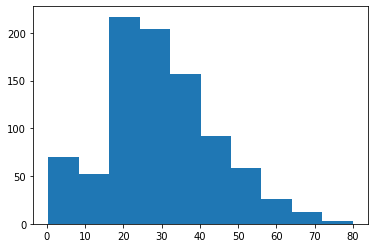

In [16]:
# Plot a histogram on Age

plt.hist(train['Age'])

In [17]:
# Plot a piechart on survived people

survived = train[train['Survived'] == 1]
notsurvived = train[train['Survived'] == 0]

print("Survived: ", len(survived))
print("Not_Survived: ", len(notsurvived))

Survived:  342
Not_Survived:  549


array([<AxesSubplot:ylabel='0'>], dtype=object)

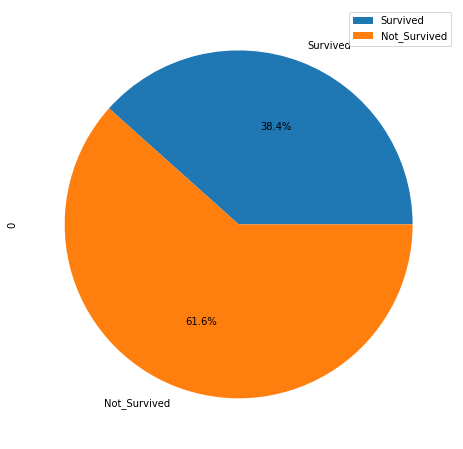

In [18]:
ppl_survived = pd.DataFrame([ len(survived), len(notsurvived)], index=['Survived', 'Not_Survived'])
ppl_survived.plot(kind = 'pie', subplots = True, figsize=(16,8), autopct = '%1.1f%%' )

In [19]:
# Find survived and not_survived in both gender

gender = train['Sex'].unique()
gender

array(['male', 'female'], dtype=object)

In [20]:
len(train[(train['Survived'] == 1) & (train['Sex'] == 'male') ])

109

In [21]:
# return the survived people in both gender

def gendersurvived(gen):
    return len(train[(train['Survived'] == 1) & (train['Sex'] == gen) ])

# return the not_survived people in both gender

def gendernot_survived(gen):
    return len(train[(train['Survived'] == 0) & (train['Sex'] == gen) ])

In [22]:
# make a list of both gender, survived, not_survived and total people. Then merge it into one dataframe

gender_list = list()
genderSurvived_list = list()
genderNotsurvived_list = list()
genderTotal_list = list()

# append all details in respective list

for gen in gender:
    survived_gen = gendersurvived(gen)
    notsurvived_gen = gendernot_survived(gen)
    totalppl_gen = survived_gen + notsurvived_gen
    gender_list.append(gen)
    genderSurvived_list.append(survived_gen)
    genderNotsurvived_list.append(notsurvived_gen)
    genderTotal_list.append(totalppl_gen)

In [23]:
print('gender_list: ', gender_list)
print('genderSurvived_list: ', genderSurvived_list)
print('genderNotsurvived_list: ', genderNotsurvived_list)


gender_list:  ['male', 'female']
genderSurvived_list:  [109, 233]
genderNotsurvived_list:  [468, 81]


In [24]:
train['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [25]:
# Let's make a dataframe of it

gender_df = pd.DataFrame({
    "Gender" : gender_list,
    "Gender_Survived" : genderSurvived_list,
    "Gender_notSurvived" : genderNotsurvived_list,
    "Gender_Total" : genderTotal_list
}, columns=['Gender', 'Gender_Survived', 'Gender_notSurvived', 'Gender_Total'])

# Sorting into descending orders

gender_df.sort_values('Gender_Total', ascending=False, inplace=True)

gender_df.head()

,Gender,Gender_Survived,Gender_notSurvived,Gender_Total
0,male,109,468,577
1,female,233,81,314


In [26]:
def groupedGraph(start,end):
    # set width of bar
    barWidth = 0.20

    # set height of bar
    bars1 = gender_df['Gender_Survived'][start:end]
    bars2 = gender_df['Gender_notSurvived'][start:end]
    bars3 = gender_df['Gender_Total'][start:end]

    # Set position of bar on X axis
    r1 = np.arange(bars1.size)
    r2 = [x + barWidth for x in r1]
    r3 = [x + barWidth for x in r2]

    # Make the plot
    plt.bar(r1, bars1, color='#36688D', width=barWidth, edgecolor='white', label='Survived')
    plt.bar(r2, bars2, color='#F3CD05', width=barWidth, edgecolor='white', label='notSurvived')
    plt.bar(r3, bars3, color='#F49F05', width=barWidth, edgecolor='white', label='Total People')

    # Add xticks on the middle of the group bars
    plt.xticks([r + barWidth for r in range(len(bars1))], gender_df['Gender'][start:end])

    # Create legend & Show graphic
    plt.legend()


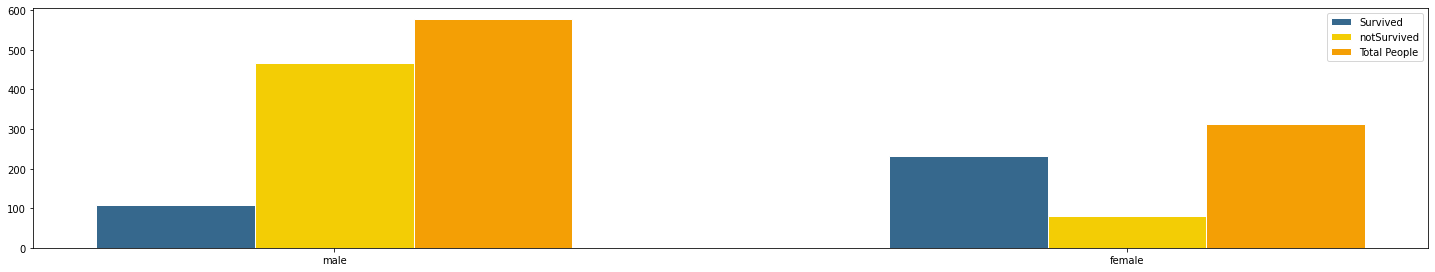

In [27]:
#Let's visualize this dataframe into the Grouped barplot

fig = plt.figure(figsize=(25,15))

plt.subplot(311)
groupedGraph(0,2)

In [28]:
# Label encoding on Embarked value

from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
train['encode_embarked'] = label_encoder.fit_transform(train['Embarked'])
test['encode_embarked'] = label_encoder.fit_transform(test['Embarked'])


train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,encode_embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,2


In [29]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,encode_embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,2
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,2
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,2


In [30]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
train['Gender'] = label_encoder.fit_transform(train['Sex'])
test['Gender'] = label_encoder.fit_transform(test['Sex'])

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,encode_embarked,Gender
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,2,1


In [31]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,encode_embarked,Gender
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,1,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,2,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,1,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,2,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,2,0


In [32]:
# feature selection

# # let's consider necessary columns

data1 = train[['Survived','Pclass','Gender','Age','Fare','encode_embarked']]
data1

,Survived,Pclass,Gender,Age,Fare,encode_embarked
0,0,3,1,22.0,7.2500,2
1,1,1,0,38.0,71.2833,0
2,1,3,0,26.0,7.9250,2
3,1,1,0,35.0,53.1000,2
4,0,3,1,35.0,8.0500,2
...,...,...,...,...,...,...
886,0,2,1,27.0,13.0000,2
887,1,1,0,19.0,30.0000,2
888,0,3,0,26.0,23.4500,2
889,1,1,1,26.0,30.0000,0


In [33]:
data2 = test[['Pclass','Gender','Age','Fare','encode_embarked']]
data2

,Pclass,Gender,Age,Fare,encode_embarked
0,3,1,34.5,7.8292,1
1,3,0,47.0,7.0000,2
2,2,1,62.0,9.6875,1
3,3,1,27.0,8.6625,2
4,3,0,22.0,12.2875,2
...,...,...,...,...,...
413,3,1,28.0,8.0500,2
414,1,0,39.0,108.9000,0
415,3,1,38.5,7.2500,2
416,3,1,38.5,8.0500,2


In [34]:
data1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Gender           891 non-null    int64  
 3   Age              891 non-null    float64
 4   Fare             891 non-null    float64
 5   encode_embarked  891 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 41.9 KB


In [35]:
X = data1.drop('Survived', axis=1)
y = data1['Survived']

In [36]:
data1.head()

,Survived,Pclass,Gender,Age,Fare,encode_embarked
0,0,3,1,22.0,7.2500,2
1,1,1,0,38.0,71.2833,0
2,1,3,0,26.0,7.9250,2
3,1,1,0,35.0,53.1000,2
4,0,3,1,35.0,8.0500,2


In [37]:
X.head()

,Pclass,Gender,Age,Fare,encode_embarked
0,3,1,22.0,7.2500,2
1,1,0,38.0,71.2833,0
2,3,0,26.0,7.9250,2
3,1,0,35.0,53.1000,2
4,3,1,35.0,8.0500,2


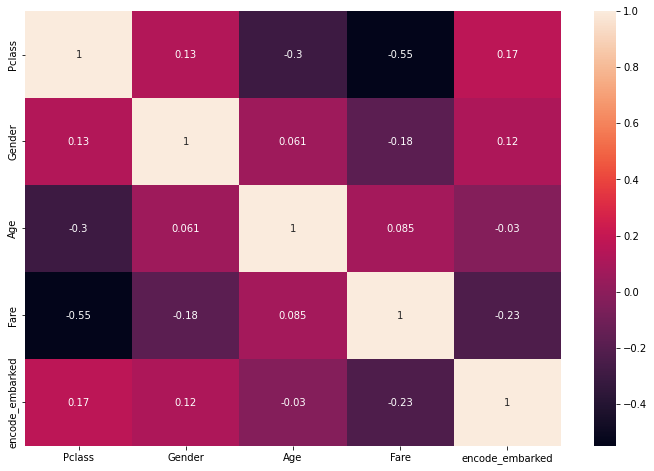

In [38]:
# now, plot the dataset

plt.figure(figsize=(12,8))
ax = sns.heatmap(X.corr(), annot=True)
plt.show()

In [39]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [40]:
corr_features = correlation(X, 0.5)
len(set(corr_features))

1

In [41]:
corr_features

{'Fare'}

In [42]:
X_corr = X.drop(corr_features,axis=1)
X_corr

,Pclass,Gender,Age,encode_embarked
0,3,1,22.0,2
1,1,0,38.0,0
2,3,0,26.0,2
3,1,0,35.0,2
4,3,1,35.0,2
...,...,...,...,...
886,2,1,27.0,2
887,1,0,19.0,2
888,3,0,26.0,2
889,1,1,26.0,0


In [43]:
test_data = data2.drop('Fare', axis=1)
test_data

,Pclass,Gender,Age,encode_embarked
0,3,1,34.5,1
1,3,0,47.0,2
2,2,1,62.0,1
3,3,1,27.0,2
4,3,0,22.0,2
...,...,...,...,...
413,3,1,28.0,2
414,1,0,39.0,0
415,3,1,38.5,2
416,3,1,38.5,2


In [44]:
x_train, x_test,y_train,y_test = train_test_split(X_corr,y,test_size =0.3)

# print the data
x_train

,Pclass,Gender,Age,encode_embarked
545,1,1,64.0,2
734,2,1,23.0,2
719,3,1,33.0,2
838,3,1,32.0,2
540,1,0,36.0,2
...,...,...,...,...
148,2,1,36.5,2
222,3,1,51.0,2
577,1,0,39.0,2
781,1,0,17.0,2


In [45]:
print('x_train: ', x_train.shape)
print('x_test: ', x_test.shape)
print('y_train: ', y_train.shape)
print('y_test: ', y_test.shape)

x_train:  (623, 4)
x_test:  (268, 4)
y_train:  (623,)
y_test:  (268,)


In [46]:
# Model selection and implimentation (logistic regression`)

from sklearn.linear_model import LogisticRegression

In [47]:
clf = LogisticRegression()

clf.fit(x_train,y_train)

LogisticRegression()

In [48]:
pred = clf.predict(x_test)
pred

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0])

In [49]:
# Model Evaluation

clf.score(x_test,y_test)

0.7798507462686567

In [50]:
# Confusion Metrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
cm

array([[135,  25],
       [ 34,  74]])

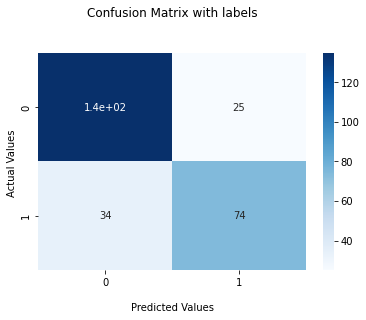

In [51]:
# now, visualize confusion metrix

ax = sns.heatmap(cm, annot=True, cmap='Blues')

ax.set_title('Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');


## Display the visualization of the Confusion Matrix.
plt.show()


In [52]:
fnl = clf.predict(test_data)
fnl

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [53]:
fnl = pd.DataFrame(fnl,columns=['Survived'])
sub = pd.concat([test['PassengerId'],fnl],axis=1)

sub.set_index('PassengerId',inplace=True)

sub.to_csv("submission.csv")